In [1]:
import numpy as np
import sympy as sp 
import volterra_collocation_solver as vcs
import matplotlib.pyplot as plt
from IPython.display import display, Math

from collections import namedtuple

In [2]:
plt.rcParams['figure.figsize'] = [10,8]
plt.rcParams['font.size'] = 14

# Main Parameters

In [3]:
sim_time = 3.0
sim_dts = [0.001]
#sim_dts = [0.09, 0.03, 0.01, 0.003, 0.001]

In [4]:
# The collocation parameters are c/coll_divs for each c in coll_choices
coll_divs = 3
coll_choices_VIE_1 = [1,2,3]
coll_choices_VIE_2 = [0,1,2,3]
coll_choices_VIDE  = [0,1,2,3]

force_continuous_VIE_1 = False

In [5]:
c_noise_coef = 0.0
c_dot_noise_coef = 0.0
c_ddot_noise_coef = 0.0
k1_noise_coef = 0.0
k3_noise_coef = 0.0

# Define $C$ and $\Omega$, and compute $\dot{C}$, $\ddot{C}$, $K_1$, $K_3$ symbolically

In [6]:
u, s = sp.symbols('u s', real=True)

sym_c = 5 * sp.exp(-3 * u**2)*sp.cos(4.99 * u)
# test_func_1 = 0.5 * sp.sin(4*u + sp.pi/2)*sp.exp(-5.0*u)
# test_func_2 = 0.5 * sp.sin(3.73*u)*sp.exp(-2*u)

# sym_c = test_func_1 + test_func_2
c_func = sp.lambdify(u, sym_c)

# Normalize so C(0) = 1
sym_c = (1/c_func(0))*sym_c
c_func = sp.lambdify(u, sym_c)


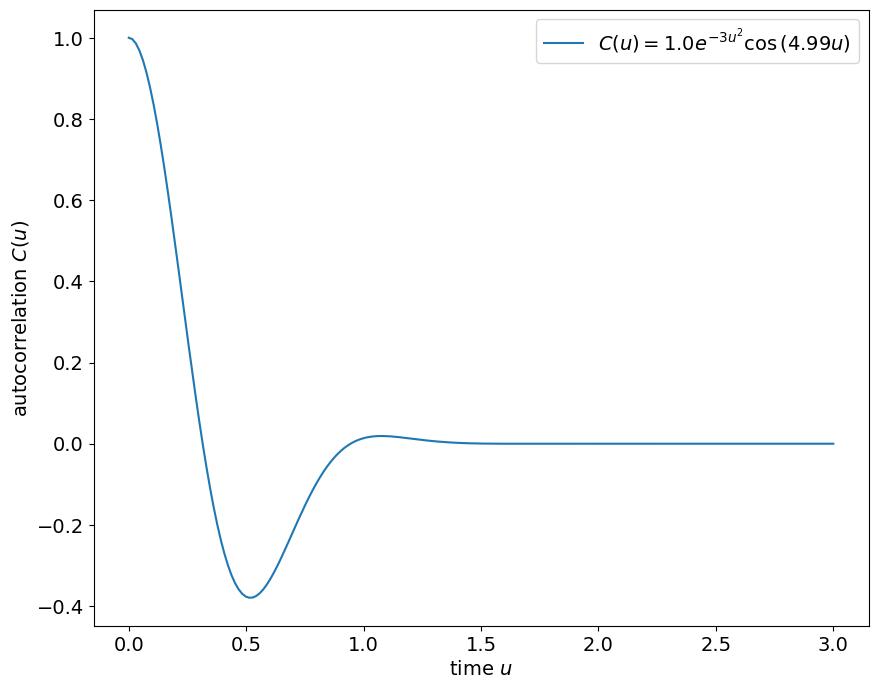

In [7]:
u_vals = np.linspace(0, sim_time, 200)
plt.plot(u_vals, [c_func(u) for u in u_vals],
         label=f"$C(u)={sp.latex(sym_c)}$")
plt.xlabel("time $u$")
plt.ylabel("autocorrelation $C(u)$")
plt.legend();

In [8]:
sym_c_dot = sp.diff(sym_c)
sym_c_ddot = sp.diff(sym_c_dot)

c_dot_func = sp.lambdify(u, sym_c_dot)
c_ddot_func = sp.lambdify(u, sym_c_ddot)

# TO DO: Figure out how to set u=0 in sym_c_dot
omega = c_dot_func(0)

sym_k3 = (1.0/c_func(0)) * sym_c_dot
sym_k1 = (1.0/c_func(0)) * sym_c_ddot - sym_k3 * omega 
k1_func = sp.lambdify(u, sym_k1)
k3_func = sp.lambdify(u, sym_k3)

In [9]:
display(Math("\\Large C(u)=" + sp.latex(sym_c)))
display(Math("\\Large \\dot{C}(u)=" + sp.latex(sym_c_dot)))
display(Math("\\Large \\ddot{C}(u)=" + sp.latex(sym_c_ddot)))
display(Math("\\Large K_3(u)=C(0)^{-1}\\dot{C}(u)=" + sp.latex(sym_k3)))
display(Math("\\Large K_1(u)=C(0)^{-1}\\ddot{C}(u)-K_3(u)\\Omega=" + sp.latex(sym_k1)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# Create list of values for $C$, $\dot{C}$, $\ddot{C}$, $K_1$ and $K_3$

In [10]:
# initialize many empty lists
num_mesh_intervals, num_data_pts, data_times, \
c_data,  c_dot_data,  c_ddot_data,  k1_data,  k3_data, \
c_noise, c_dot_noise, c_ddot_noise, k1_noise, k3_noise \
= [[] for i in range(13)]

In [11]:
for indx, sim_dt in enumerate(sim_dts):
    num_mesh_intervals.append(int(sim_time / (sim_dt * coll_divs**2)))
    num_data_pts.append(num_mesh_intervals[indx] * coll_divs**2 + 1)
    data_times.append(np.array(
        [i*sim_dt for i in range(num_data_pts[indx])]))

for i in range(len(sim_dts)):
    c_noise.append(np.array(
        [c_noise_coef * np.random.normal(0,1) for t in data_times[i]]))
    c_dot_noise.append(np.array(
        [c_dot_noise_coef * np.random.normal(0,1) for t in data_times[i]]))
    c_ddot_noise.append(np.array(
        [c_ddot_noise_coef * np.random.normal(0,1) for t in data_times[i]]))
    k1_noise.append(np.array(
        [k1_noise_coef * np.random.normal(0,1) for t in data_times[i]]))
    k3_noise.append(np.array(
        [k3_noise_coef * np.random.normal(0,1) for t in data_times[i]]))

for i in range(len(sim_dts)):    
    c_data.append(
        [c_func(t) for t in data_times[i]] + c_noise[i])
    c_dot_data.append(
        [c_dot_func(t) for t in data_times[i]] + c_dot_noise[i])
    c_ddot_data.append(
        [c_ddot_func(t) for t in data_times[i]] + c_ddot_noise[i])
    k1_data.append(
        [k1_func(t) for t in data_times[i]] + k1_noise[i])
    k3_data.append(
        [k3_func(t) for t in data_times[i]] + k3_noise[i])

# Solve for $K$ using $C$, $\dot{C}$, and $\Omega$ and the VIE-1

## $\displaystyle \quad \frac{dC}{dt} - C(t)\Omega = \int_0^t K(t-s)C(s)ds.$

In [12]:
%%time
solns_K_from_C = []
for indx in range(len(sim_dts)):
    solns_K_from_C.append(vcs.solve_VIE_1(
        g_values=c_dot_data[indx] - c_data[indx] * omega,
        kernel_values=c_data[indx],
        soln_init_value=float('nan'),
        time_step=sim_dts[indx],
        coll_divs=coll_divs,
        coll_choices=coll_choices_VIE_1,
        return_polys=False,
        force_continuous=force_continuous_VIE_1))

CPU times: user 8.75 s, sys: 566 ms, total: 9.32 s
Wall time: 9.41 s


# Solve for $K$ using $K_1$ and $K_3$, and the VIE-2

## $\quad \displaystyle K(t) = K_1(t) + \int_0^t K_3(t-s)K(s)ds.$

In [13]:
%%time
solns_K_from_K1_K3 = []
for indx in range(len(sim_dts)):                   
    solns_K_from_K1_K3.append(vcs.solve_VIE_2(
        g_values=k1_data[indx],
        kernel_values=-k3_data[indx],
        time_step=sim_dts[indx],
        coll_divs=coll_divs, 
        coll_choices=coll_choices_VIE_2,
        return_polys=False))

CPU times: user 2.05 s, sys: 143 ms, total: 2.2 s
Wall time: 2.2 s


# Plot the two computed $K$ functions, and their difference

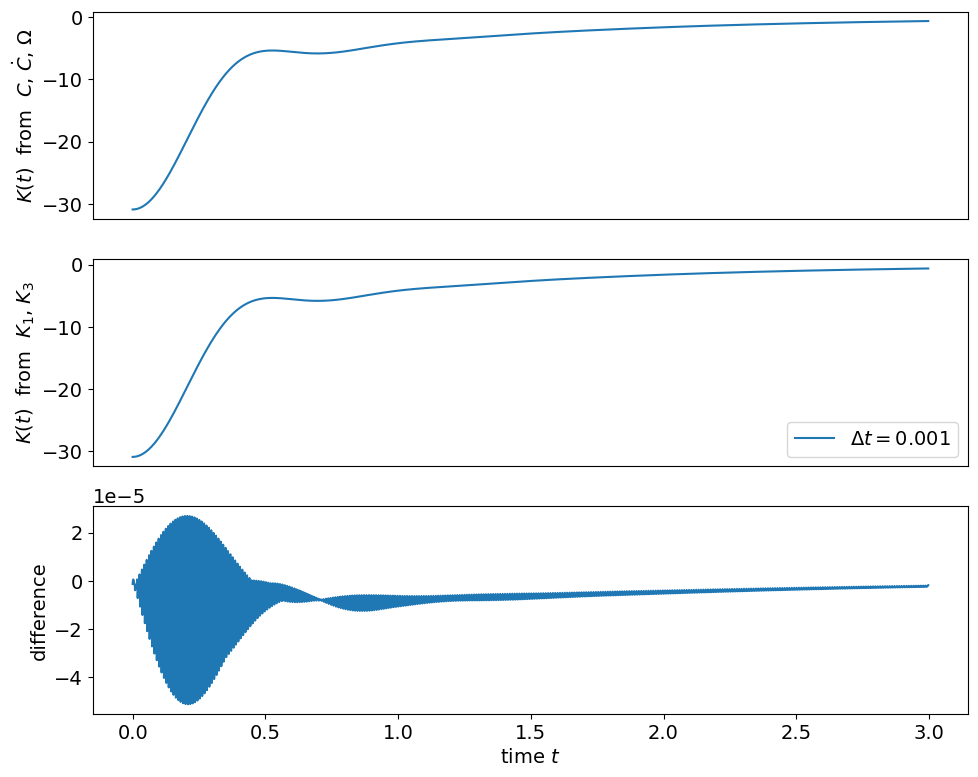

In [14]:
fig, axs = plt.subplots(3)
for indx in range(len(sim_dts)):
    axs[0].plot(data_times[indx], solns_K_from_C[indx],
                label=f"sim_dt={sim_dts[indx]}")
    axs[1].plot(data_times[indx], solns_K_from_K1_K3[indx],
                label=f"$\\Delta t={sim_dts[indx]}$")
    axs[2].plot(data_times[indx], solns_K_from_C[indx] - solns_K_from_K1_K3[indx],
                label=f"$\\Delta t={sim_dts[indx]}$")
    
axs[0].set_ylabel("$K(t)$  from  $C$, $\\dot{C}$, $\\Omega$")
axs[0].get_xaxis().set_visible(False)
axs[1].set_ylabel("$K(t)$  from  $K_1$, $K_3$")
axs[1].get_xaxis().set_visible(False)
axs[2].set_ylabel("difference")
axs[2].set_xlabel("time $t$")
axs[1].legend()
plt.tight_layout()

# Solve for $C$ using $K$, $\Omega$, and $C(0)$ via the VIDE

## $\quad \displaystyle \frac{dC}{dt} = C(t)\Omega + \int_0^t K(t-s)C(s)ds.$

## 1) Solve using the $K$ computed from $C$, $\dot{C}$, and $\Omega$

In [15]:
%%time
solns_C_from_K_from_C = []
for indx in range(len(sim_dts)):
    solns_C_from_K_from_C.append(vcs.solve_VIDE(
        a_values=c_data[indx] * omega,
        g_values=np.zeros_like(c_data[indx]),
        kernel_values=solns_K_from_C[indx],
        soln_init_value=c_func(0),
        coll_divs=coll_divs,
        coll_choices=coll_choices_VIDE,
        time_step=sim_dts[indx],
        return_polys=False))

CPU times: user 8.5 s, sys: 677 ms, total: 9.17 s
Wall time: 9.14 s


## 2) Solve using the $K$ computed from $K_1$ and $K_3$

In [16]:
%%time
solns_C_from_K_from_K1_K3 = []
for indx in range(len(sim_dts)):
    solns_C_from_K_from_K1_K3.append(vcs.solve_VIDE(
        a_values=c_data[indx] * omega,
        g_values=np.zeros_like(c_data[indx]),
        kernel_values=solns_K_from_K1_K3[indx],
        soln_init_value=c_func(0),
        coll_divs=coll_divs,
        coll_choices=coll_choices_VIDE,
        time_step=sim_dts[indx],
        return_polys=False))

CPU times: user 5.74 s, sys: 616 ms, total: 6.36 s
Wall time: 6.39 s


# Plot the solutions for the two methods used to compute $C(t)$ and their errors

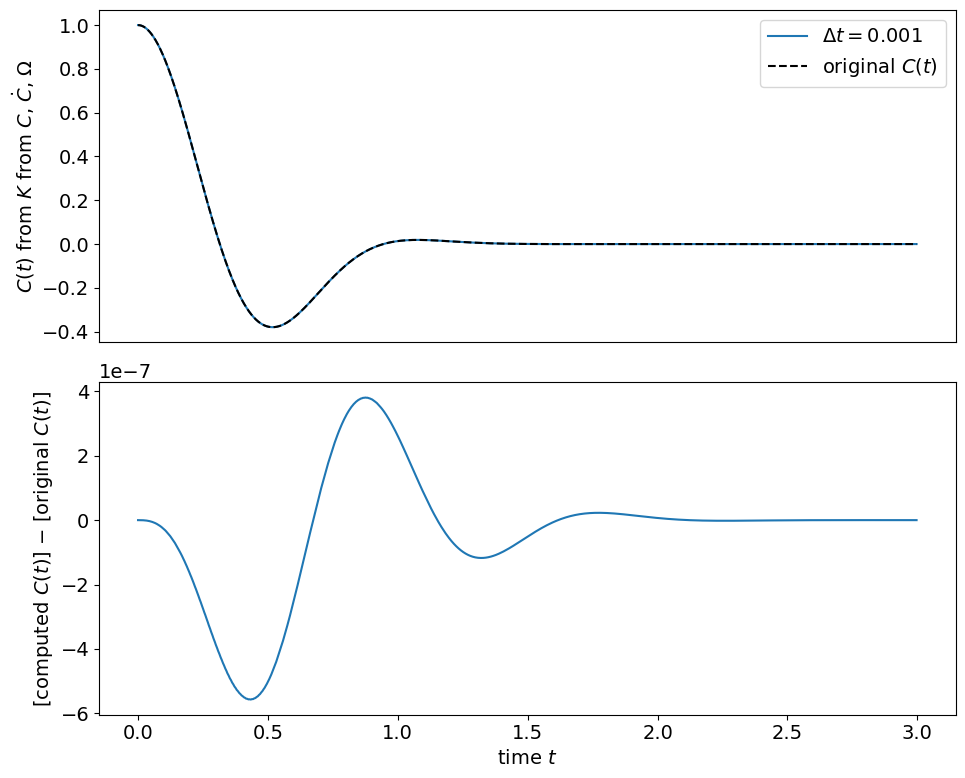

In [17]:
fig, axs = plt.subplots(2)
errors_C_K_C = []
for indx in range(len(sim_dts)):
    axs[0].plot(data_times[indx], solns_C_from_K_from_C[indx],
             label=f"$\\Delta t={sim_dts[indx]}$")
    errors_C_K_C.append(solns_C_from_K_from_C[indx] - c_data[indx])
    axs[1].plot(data_times[indx], errors_C_K_C[-1],
                label=f"$\\Delta t={sim_dts[indx]}$")
axs[0].plot(data_times[0], c_data[0], 'k--', label=f"original $C(t)$")    
axs[0].set_ylabel("$C(t)$ from $K$ from $C$, $\\dot{C}$, $\\Omega$")
axs[0].get_xaxis().set_visible(False)
axs[1].set_ylabel("$K(t)$  from  $K_1$, $K_3$")
axs[1].set_ylabel("[computed $C(t)$] $-$ [original $C(t)$]")
axs[1].set_xlabel("time $t$")
axs[0].legend()
plt.tight_layout();

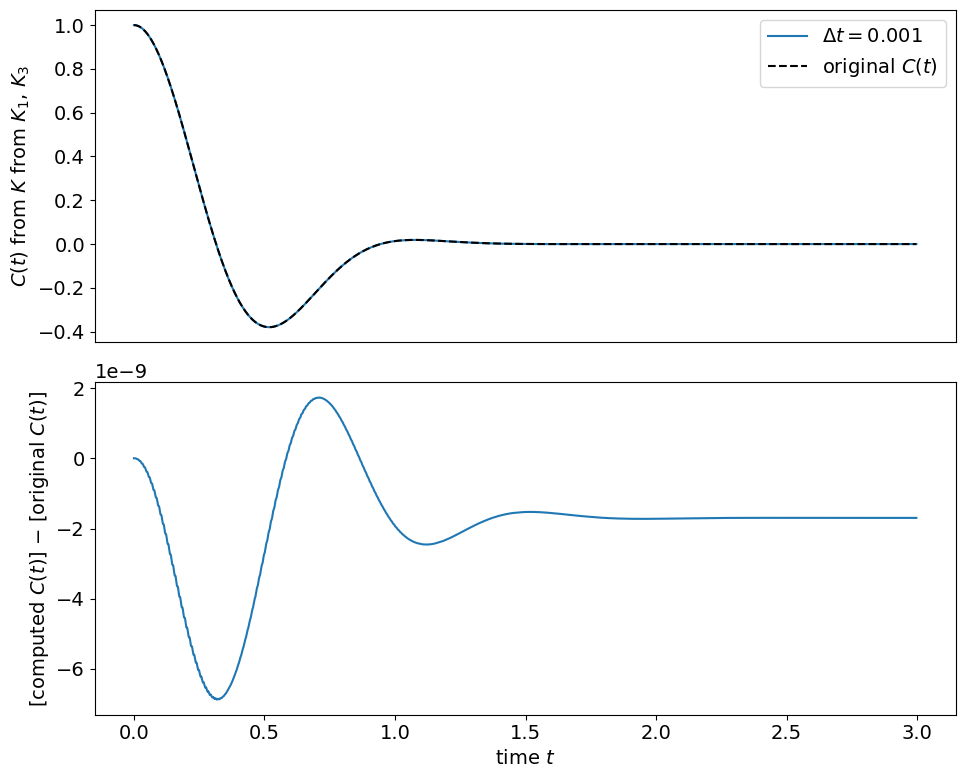

In [18]:
fig, axs = plt.subplots(2)
errors_C_K_K1K3 = []
for indx in range(len(sim_dts)):
    axs[0].plot(data_times[indx], solns_C_from_K_from_K1_K3[indx],
             label=f"$\\Delta t={sim_dts[indx]}$")
    errors_C_K_K1K3.append(solns_C_from_K_from_K1_K3[indx] - c_data[indx])
    axs[1].plot(data_times[indx], errors_C_K_K1K3[-1],
                label=f"$\\Delta t={sim_dts[indx]}$")
axs[0].plot(data_times[0], c_data[0], 'k--', label=f"original $C(t)$")    
axs[0].set_ylabel("$C(t)$ from $K$ from $K_1$, $K_3$")
axs[0].get_xaxis().set_visible(False)
axs[1].set_ylabel("$K(t)$  from  $K_1$, $K_3$")
axs[1].set_ylabel("[computed $C(t)$] $-$ [original $C(t)$]")
axs[1].set_xlabel("time $t$")
axs[0].legend()
plt.tight_layout();

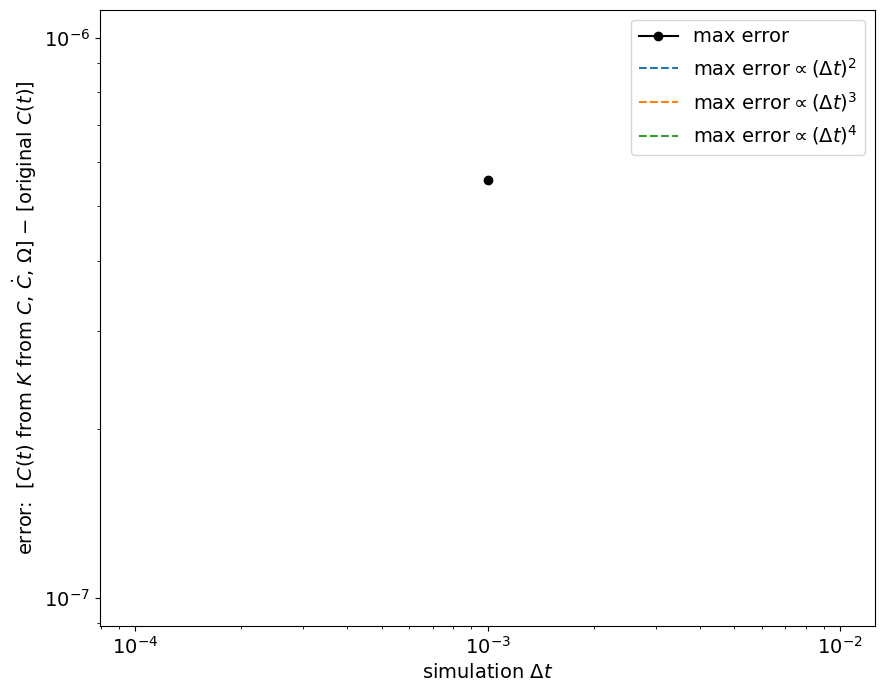

In [19]:
max_errors_C_K_C = np.array([np.max(np.abs(errors)) for errors in errors_C_K_C])
plt.plot(sim_dts, max_errors_C_K_C,  'ko-', label="max error", zorder=10)
for err_pow in [2,3,4]:
    plt.plot(sim_dts, [max_errors_C_K_C[0]*(x/sim_dts[0])**err_pow for x in sim_dts],
             '--', label=f"max error$\\propto (\\Delta t)^{err_pow}$")
plt.xlabel("simulation $\\Delta t$")
plt.xscale('log')
plt.yscale('log')
plt.ylabel("error:  [$C(t)$ from $K$ from $C$, $\\dot{C}$, $\\Omega$] $-$ [original $C(t)$]")
plt.legend();

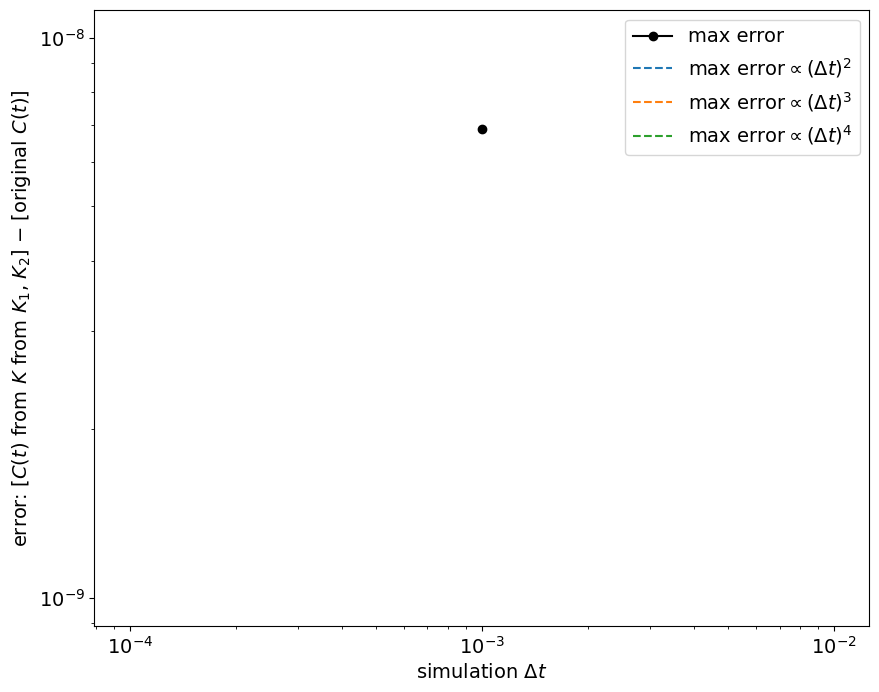

In [20]:
max_errors_C_K_K1K3 = np.array([np.max(np.abs(errors)) for errors in errors_C_K_K1K3])

plt.plot(sim_dts, max_errors_C_K_K1K3,  'ko-', label="max error", zorder=10)
for err_pow in [2,3,4]:
    plt.plot(sim_dts, [max_errors_C_K_K1K3[0]*(x/sim_dts[0])**err_pow for x in sim_dts],
             '--', label=f"max error$\\propto (\\Delta t)^{err_pow}$")
plt.xlabel("simulation $\\Delta t$")
plt.xscale('log')
plt.yscale('log')
plt.ylabel("error: [$C(t)$ from $K$ from $K_1$, $K_2$] $-$ [original $C(t)$]")
plt.legend();

In [21]:
# TO DO:
# 1) What happens when we find C_dot and/or C_ddot using numerical methods?
# 2) What happens when we add noise to the data flow at various stages?
# 3) Maybe look at more realistic noise functions, i.e. smoother and grow with time
# 4) Try forcing continuity
# 5) Find an example with an exact solution for memory kernel K. (Laplace transform)